# Práctica Final: Clasificación con Scikit-learn y MLflow

En esta práctica, utilizarás un conjunto de datos de Scikit-learn (podeís usar el mismo que en el notebook de Intro MLFlow) para entrenar un modelo de clasificación.

Pasos a seguir: 

    Exploración de Datos: Analiza el conjunto de datos proporcionado para comprender su estructura y contenido.

    Preprocesamiento de Texto: Realiza tareas de preprocesamiento de texto, como tokenización y vectorización, para preparar los datos para el modelado.

    Entrenamiento del Modelo: Utiliza algoritmos de clasificación de Scikit-learn para entrenar un modelo con los datos preprocesados.

    Evaluación del Modelo: Evalúa el rendimiento del modelo utilizando métricas de evaluación estándar como precisión y recall.

    Registro de Métricas con MLflow: Utiliza MLflow para registrar métricas y hiperparámetros durante el entrenamiento, facilitando la gestión y comparación de experimentos.


Nota: Dado que no voy a poder tener acceso a vuestros logs de MLFlow añadirme las imagenes de la interfaz de MLFlow en el notebook

**1.EXPLORACIÓN DE DATOS:**

In [2]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score

from sklearn.datasets import load_wine

In [3]:

vinos = load_wine()

In [4]:

df = pd.DataFrame(vinos['data'], columns=vinos['feature_names'])
df['target'] = vinos['target']

In [5]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [9]:
print("\nPrimeras filas:")
df.head()


Primeras filas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [10]:

print("\nInformación general:")
df.info()


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null

In [11]:

print("\nInformación estadística:")
df.describe()


Información estadística:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [13]:
print("Conteo tipo de vino:")
print(df['target'].value_counts())

Conteo tipo de vino:
target
1    71
0    59
2    48
Name: count, dtype: int64


In [14]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


**2. PREPROCESAMIENTO DE TEXTO:**


Para esta práctica he seleccionado el dataset de Vinos (Wine) de Scikit-learn. Al tratarse de un conjunto de datos numérico, no se aplican técnicas de tokenización o vectorización, ya que estas son específicas para modelos de NLP (texto). 

**3.ENTRENAMIENTO DEL MODELO:**


In [15]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['target'])

In [16]:

test_df.drop('target', axis=1).to_csv('test_vinos.csv', index=False)
test_df[['target']].to_csv('test-target_vinos.csv', index=False)

In [17]:

features = [col for col in train_df.columns if col not in ['target', 'target_name']]
x_raw = train_df[features]
y_raw = train_df['target']


x_train, x_val, y_train, y_val = train_test_split(
    x_raw, y_raw, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_raw)

print(f" Datos: {len(x_train)} para entrenar y {len(x_val)} para validar.")

 Datos: 113 para entrenar y 29 para validar.


In [18]:

clasificador_vinos_150 = RandomForestClassifier(
    n_estimators=150,        
    min_samples_leaf=1, 
    class_weight='balanced', 
    random_state=42)


modelo_150 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('RandomForest', clasificador_vinos_150)])



In [19]:

modelo_150.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('RandomForest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


**4.EVALUACIÓN DEL MODELO:**

In [20]:

accuracy_train = modelo_150.score(x_train, y_train)
accuracy_test = modelo_150.score(x_val, y_val)

print("Accuracy_train:", accuracy_train)
print("Accuracy_test:", accuracy_test)


configuracion = modelo_150.get_params()


Accuracy_train: 1.0
Accuracy_test: 1.0


In [22]:
# primera prueba con 150 árboles

mlflow.set_experiment("Random_Forest_modelo_vinos")

with mlflow.start_run(run_name="Modelo_150_arboles"):
    mlflow.log_metric("Accuracy_train", accuracy_train)
    mlflow.log_metric("Accuracy_test", accuracy_test)
    mlflow.log_param("n_estimators", 150)
    mlflow.sklearn.log_model(modelo_150, "Modelo_150_arboles")
    
  

2026/02/28 21:16:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 21:16:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [23]:
# segunda prueba con 75 arboles


clasificador_vinos_75 = RandomForestClassifier(
    n_estimators=75,        
    min_samples_leaf=1, 
    class_weight='balanced', 
    random_state=42)


modelo_75 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('RandomForest', clasificador_vinos_75)])

modelo_75.fit(x_train, y_train)

accuracy_train_75 = modelo_75.score(x_train, y_train)
accuracy_test_75 = modelo_75.score(x_val, y_val)

print(f"Accuracy Train: {accuracy_train_75:.4f} | Accuracy Test: {accuracy_test_75:.4f}")

Accuracy Train: 1.0000 | Accuracy Test: 1.0000


In [24]:

mlflow.set_experiment("Random_Forest_modelo_vinos")

with mlflow.start_run(run_name="Prueba_75_Arboles"):
    mlflow.log_metric("Accuracy_train", accuracy_train_75)
    mlflow.log_metric("Accuracy_test", accuracy_test_75)
    mlflow.log_param("n_estimators", 75)
    mlflow.sklearn.log_model(modelo_75, "modelo__75_arboles")
    

2026/02/28 21:16:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 21:16:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


**Registro de Experimentos y Trazabilidad con MLflow:**
A continuación, se presentan las evidencias de la interfaz de usuario donde se gestionaron los experimentos.


1. Panel general de experimentos:
![1. panel general de experimentos .jpg](<attachment:1. panel general de experimentos .jpg>)
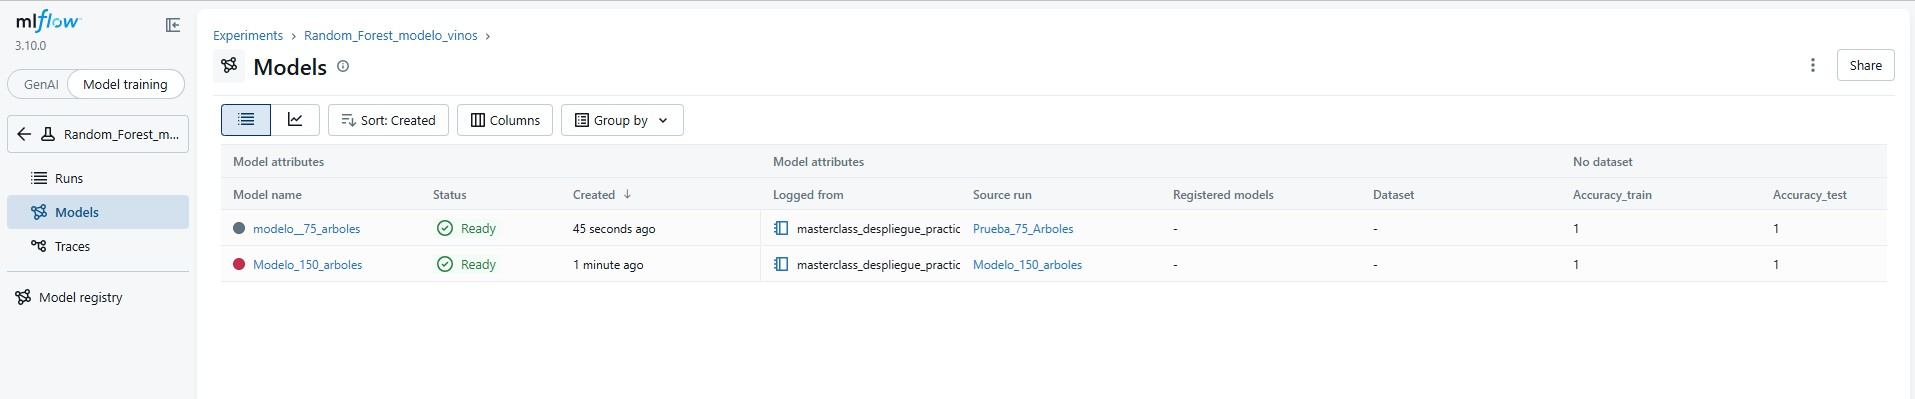

En esta imagen se pueden observar los dos modelos generados. El modelo de 150 árboles y el modelo de 75 árboles(justo su mitad).

2. Comparativa de ambos experimentos:
![2.Comparativa ambos experimentos.jpg](<attachment:2.Comparativa ambos experimentos.jpg>)
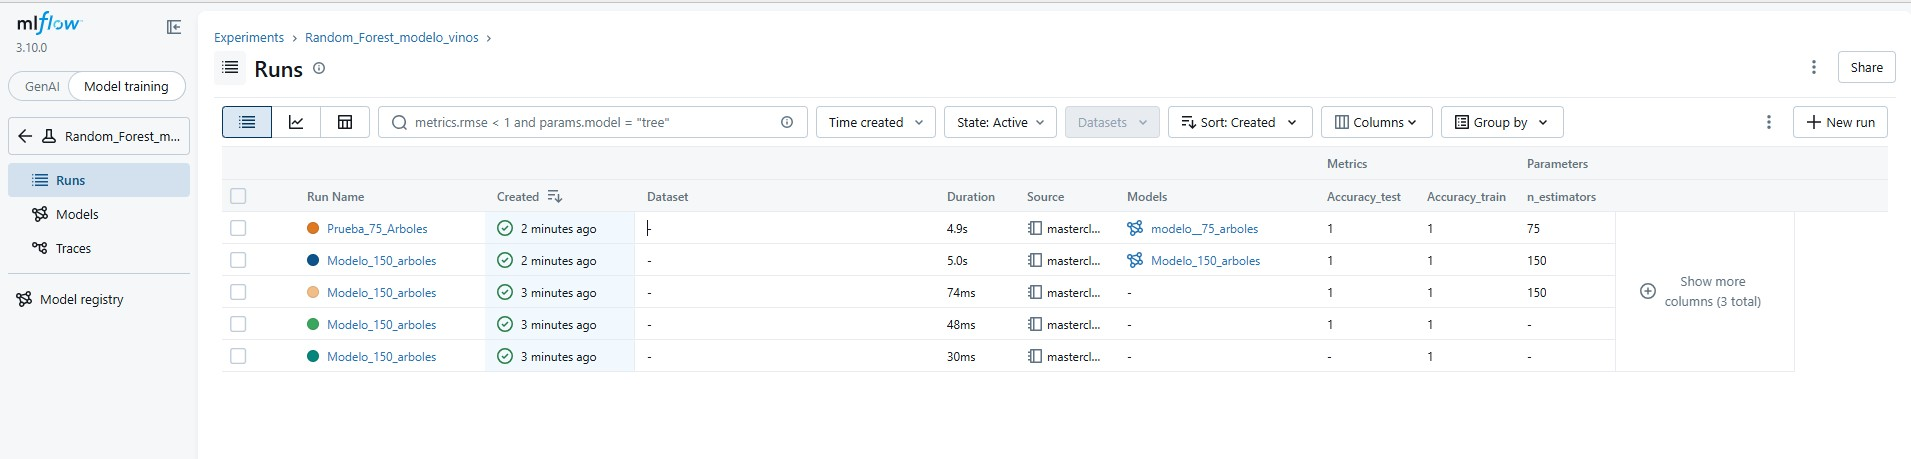

En esta captura se observa q ambos modelos tienen un Accuracy de 1.0.


3. Comparación de gáfricas de ambos modelos:
![3. comparacion de gráficas ambos modelos.jpg](<attachment:3. comparacion de gráficas ambos modelos.jpg>)
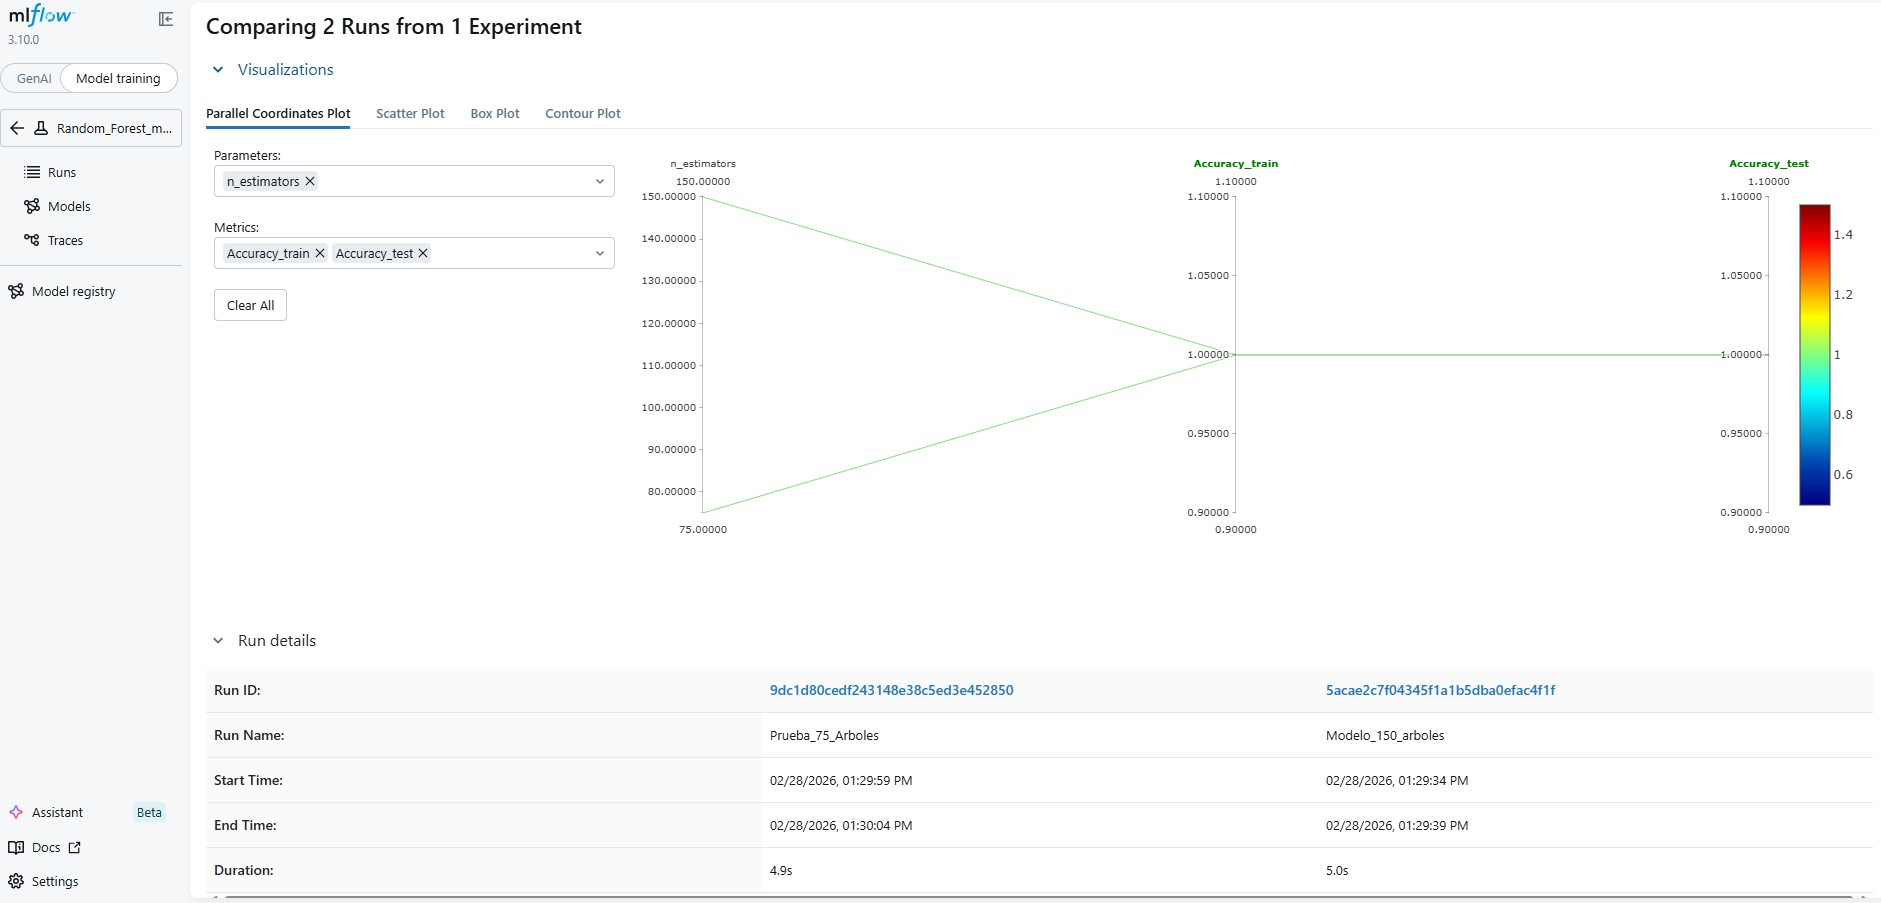

4.Modelos registrados:
![4. modelos registrados.jpg](<attachment:4. modelos registrados.jpg>)

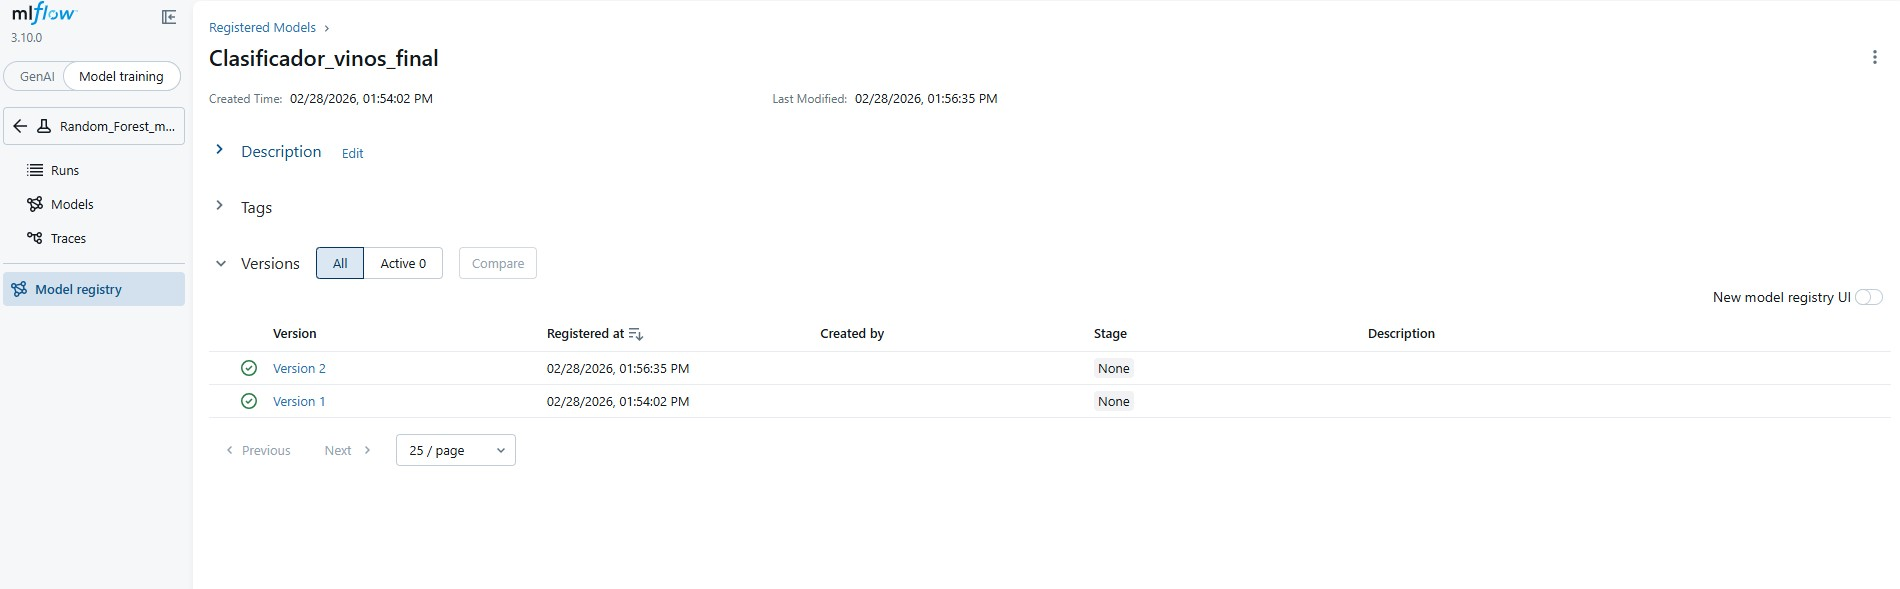

5. Modelo en producción:
![5. modelo en producción.jpg](<attachment:5. modelo en producción.jpg>)
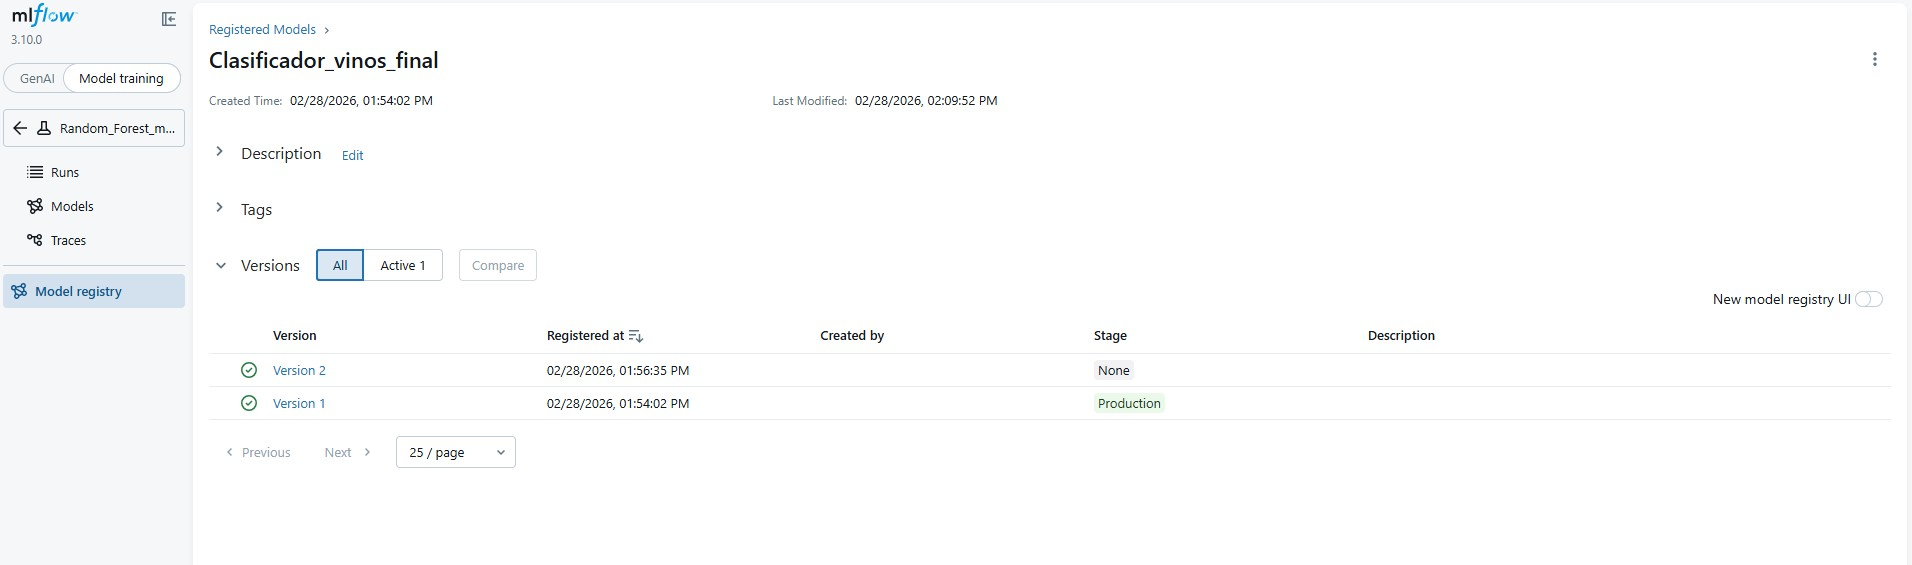

Tras comparar ambos modelos, he decidido poner en producción  el modelo de 75 árboles por los siguientes motivos:

Rendimiento Óptimo: La gráfica  demuestra que el modelo de 75 árboles alcanza un Accuracy de 1.0, exactamente igual que el modelo de 150.

Eficiencia (Navaja de Ockham):si dos modelos dan el mismo resultado, siempre elegimos el más sencillo. El de 75 árboles es más ligero, consume menos memoria y será más rápido en producción.

In [25]:

model_name = "Clasificador_vinos_final"
model_mlflow = mlflow.pyfunc.load_model(f"models:/{model_name}/Production")

In [27]:
model_mlflow

mlflow.pyfunc.loaded_model:
  artifact_path: file:///c:/Users/rocio/Escritorio/bd16/mlops-llmops-bd16/mlruns/11/models/m-b17720781aba4d0fa47489dec11b0e47/artifacts
  flavor: mlflow.sklearn
  run_id: 9dc1d80cedf243148e38c5ed3e452850

In [28]:
predicciones = model_mlflow.predict(x_val)
predicciones

array([2, 2, 1, 1, 0, 1, 1, 1, 0, 1, 0, 2, 1, 0, 2, 1, 1, 2, 0, 1, 2, 1,
       2, 2, 1, 0, 0, 0, 0])

## Generar .py de funciones y main con al menos dos argumentos de entrada.

In [30]:

from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier

def entrenar_modelo_vinos(n_trees):
    data = load_wine()
    X, y = data.data, data.target

   
    model = RandomForestClassifier(n_estimators=n_trees, random_state=42)

  
    model.fit(X, y)

    return model

In [34]:
%%writefile main.py
import argparse
import mlflow
import mlflow.sklearn
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score
from functions import entrenar_modelo_vinos

if __name__ == "__main__":
  
    parser = argparse.ArgumentParser()
    parser.add_argument("--n_trees", type=int, default=100)
    parser.add_argument("--experiment_name", type=str, default="Practica_Vinos")
    args = parser.parse_args()

   
    mlflow.set_tracking_uri("http://127.0.0.1:8080")
    mlflow.set_experiment(args.experiment_name)

  
    with mlflow.start_run():
        model = entrenar_modelo_vinos(args.n_trees)
        
     
        data = load_wine()
        acc = accuracy_score(data.target, model.predict(data.data))

        
        mlflow.log_param("n_trees", args.n_trees)
        mlflow.log_metric("accuracy", acc)
        mlflow.sklearn.log_model(model, "model")

       

Overwriting main.py


In [1]:
import os
os.system('python main.py --n_trees 100 --experiment_name "Entrega_Final"')

0

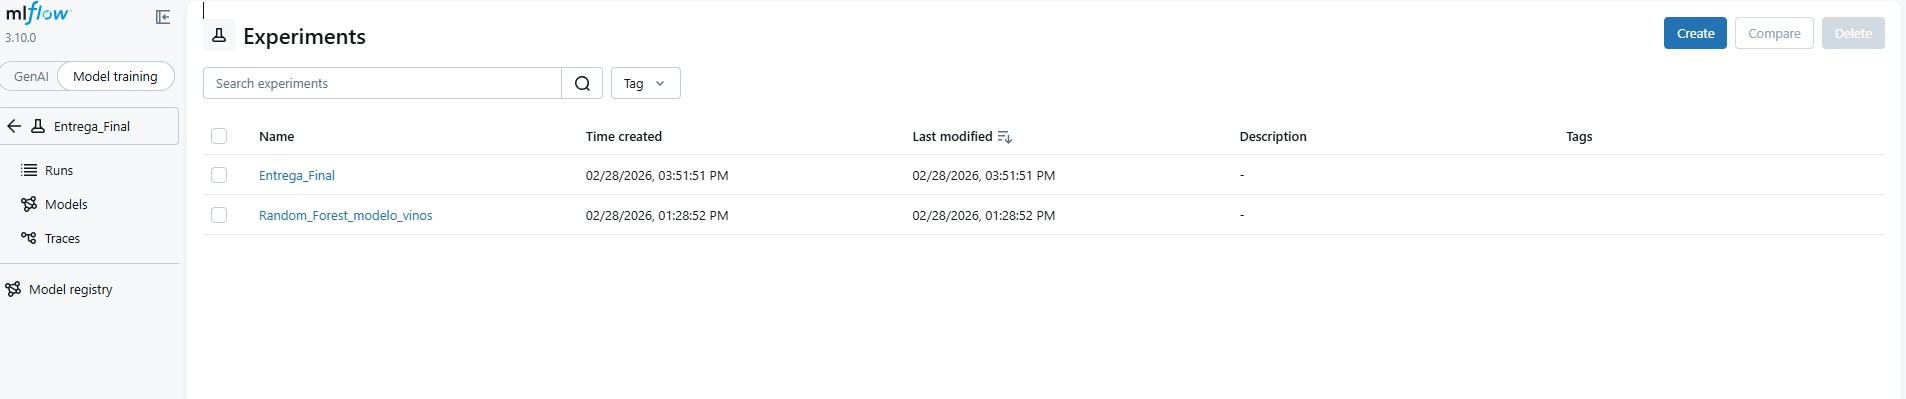

![entrega final .jpg](<attachment:entrega final .jpg>)
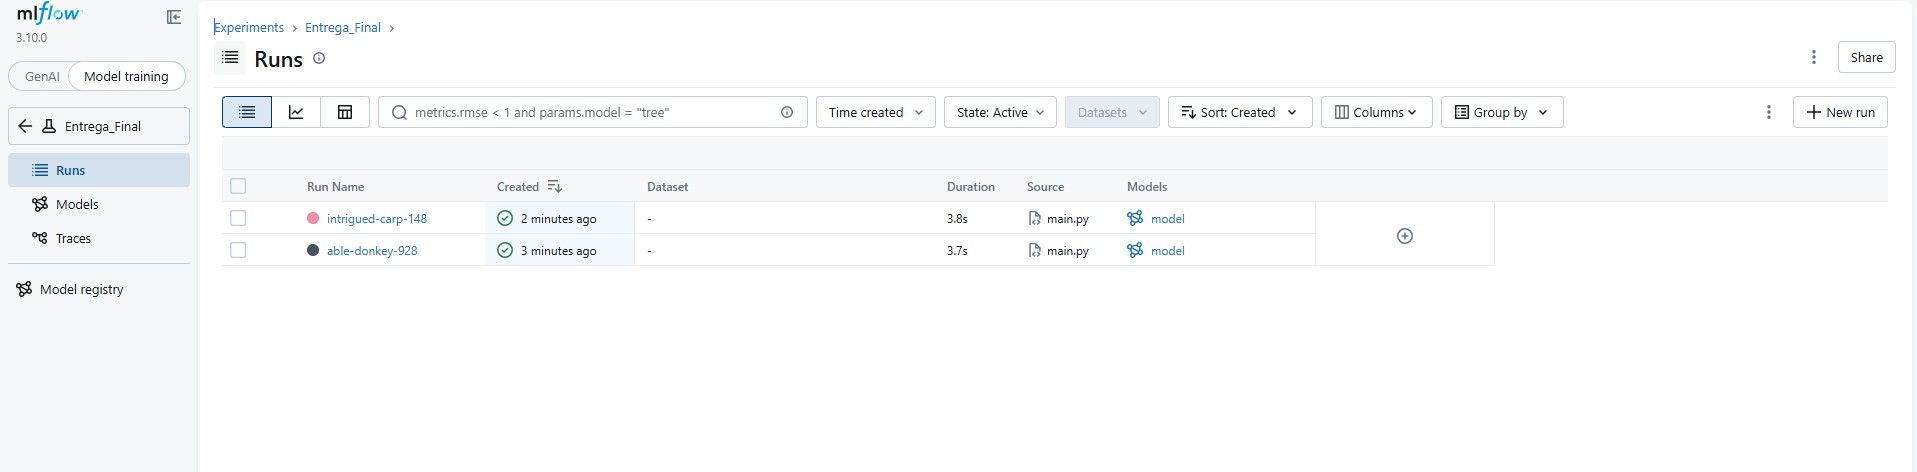